In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
import arviz as az
from arviz.labels import MapLabeller
from IPython.display import display
from sklearn.preprocessing import LabelEncoder
import pymc as pm

seed = 6420
rng = np.random.default_rng(seed)

In [2]:
data_path = 'CDC_Wastewater_Viral_Activity_Level_for_SARS-CoV-2__Influenza_A_and_RSV.csv'

In [3]:
df = pd.read_csv(data_path)


In [4]:
df['Date_Included_In_WVAL'] = pd.to_datetime(df['Date_Included_In_WVAL'])
df['Week_End'] = pd.to_datetime(df['Week_End'])


In [5]:
df.head()

,State/Territory,Counties_Served,Site,Population_Served,Source,Site_WVAL,Site_WVAL_Category,Date_Included_In_WVAL,Week_End,Pathogen_Target,date_updated
0,Alabama,Jefferson,ID:4,30000,WastewaterSCAN,1.00,Very Low,2022-10-21,2026-04-11,Influenza A virus,2026-04-17 11:01
1,Alabama,Jefferson,ID:4,30000,WastewaterSCAN,1.00,Very Low,2022-10-21,2026-04-11,RSV,2026-04-17 11:01
2,Alabama,Jefferson,ID:4,30000,WastewaterSCAN,5.30,Moderate,2022-09-23,2026-04-11,SARS-CoV-2,2026-04-17 11:01
3,Alabama,Jefferson,ID:5,77000,WastewaterSCAN,1.00,Very Low,2022-10-31,2026-04-11,Influenza A virus,2026-04-17 11:01
4,Alabama,Jefferson,ID:5,77000,WastewaterSCAN,3.98,Low,2022-10-31,2026-04-11,RSV,2026-04-17 11:01


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 482271 entries, 0 to 482270
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   State/Territory        482271 non-null  str           
 1   Counties_Served        482135 non-null  str           
 2   Site                   482271 non-null  str           
 3   Population_Served      482271 non-null  int64         
 4   Source                 482271 non-null  str           
 5   Site_WVAL              482271 non-null  float64       
 6   Site_WVAL_Category     482271 non-null  str           
 7   Date_Included_In_WVAL  482271 non-null  datetime64[us]
 8   Week_End               482271 non-null  datetime64[us]
 9   Pathogen_Target        482271 non-null  str           
 10  date_updated           482271 non-null  str           
dtypes: datetime64[us](2), float64(1), int64(1), str(7)
memory usage: 40.5 MB


In [7]:
print("Raw distribution:")
print(df['Site_WVAL'].describe())

print("Top 20 highest values:")
print(df[['State/Territory', 'Site', 'Source', 'Pathogen_Target', 'Week_End', 'Site_WVAL']]
      .sort_values('Site_WVAL', ascending=False)
      .head(20))

log_wval = np.log(df[df['Site_WVAL'] > 0]['Site_WVAL'])
print("Log-scale distribution:")
print(log_wval.describe())
print(f"99th percentile (log): {log_wval.quantile(0.99):.2f}")
print(f"99th percentile (original scale): {np.exp(log_wval.quantile(0.99)):.2f}")


Raw distribution:
count    4.822710e+05
mean     1.220970e+06
std      5.056674e+08
min      0.000000e+00
25%      1.000000e+00
50%      2.610000e+00
75%      7.130000e+00
max      2.906303e+11
Name: Site_WVAL, dtype: float64
Top 20 highest values:
       State/Territory     Site           Source    Pathogen_Target  \
295860           Maine   ID:724       CDC_Verily                RSV   
301838           Maine   ID:724       CDC_Verily                RSV   
298910           Maine   ID:724       CDC_Verily                RSV   
289898        Michigan   ID:846  State_Territory  Influenza A virus   
286755           Maine   ID:724       CDC_Verily                RSV   
294426        Virginia  ID:2003  State_Territory  Influenza A virus   
11595         Kentucky  ID:2239  State_Territory  Influenza A virus   
297466        Virginia  ID:2014  State_Territory  Influenza A virus   
292926        Michigan   ID:846  State_Territory  Influenza A virus   
22733         Kentucky  ID:2239  State_Te

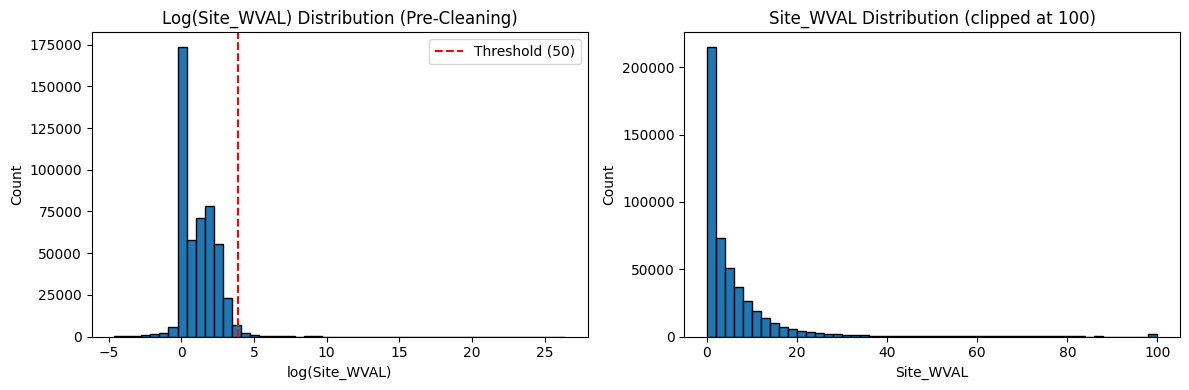

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
log_wval = np.log(df[df['Site_WVAL'] > 0]['Site_WVAL'])
axes[0].hist(log_wval, bins=50, edgecolor='black')
axes[0].set_title('Log(Site_WVAL) Distribution (Pre-Cleaning)')
axes[0].set_xlabel('log(Site_WVAL)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.log(50), color='red', linestyle='--', label='Threshold (50)')
axes[0].legend()

axes[1].hist(df['Site_WVAL'].clip(upper=100), bins=50, edgecolor='black')
axes[1].set_title('Site_WVAL Distribution (clipped at 100)')
axes[1].set_xlabel('Site_WVAL')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('wval_precleaning.png', dpi=150)
plt.show()

In [9]:
top10 = (df[['State/Territory', 'Site', 'Source', 'Pathogen_Target', 'Site_WVAL']]
         .sort_values('Site_WVAL', ascending=False)
         .head(10))
display(top10)

,State/Territory,Site,Source,Pathogen_Target,Site_WVAL
295860,Maine,ID:724,CDC_Verily,RSV,2.906303e+11
301838,Maine,ID:724,CDC_Verily,RSV,1.718520e+11
298910,Maine,ID:724,CDC_Verily,RSV,9.143403e+10
289898,Michigan,ID:846,State_Territory,Influenza A virus,3.085588e+10
286755,Maine,ID:724,CDC_Verily,RSV,2.180173e+09
294426,Virginia,ID:2003,State_Territory,Influenza A virus,6.907911e+08
11595,Kentucky,ID:2239,State_Territory,Influenza A virus,4.926913e+08
297466,Virginia,ID:2014,State_Territory,Influenza A virus,3.130802e+08
292926,Michigan,ID:846,State_Territory,Influenza A virus,1.395853e+08
22733,Kentucky,ID:2239,State_Territory,Influenza A virus,8.268735e+07


In [10]:

print(f"Rows with Site_WVAL > 100: {(df['Site_WVAL'] > 100).sum()}")
print(f"Rows with Site_WVAL > 50:  {(df['Site_WVAL'] > 50).sum()}")

df_clean = df[df['Site_WVAL'] <= 50].copy()
print(f"Removed {len(df) - len(df_clean)} rows ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")
print("Clean distribution:")
print(df_clean['Site_WVAL'].describe())

Rows with Site_WVAL > 100: 1962
Rows with Site_WVAL > 50:  4805
Removed 4805 rows (1.00%)
Clean distribution:
count    477466.000000
mean          5.283481
std           6.671446
min           0.000000
25%           1.000000
50%           2.550000
75%           6.930000
max          50.000000
Name: Site_WVAL, dtype: float64


Text(0, 0.5, 'Count')

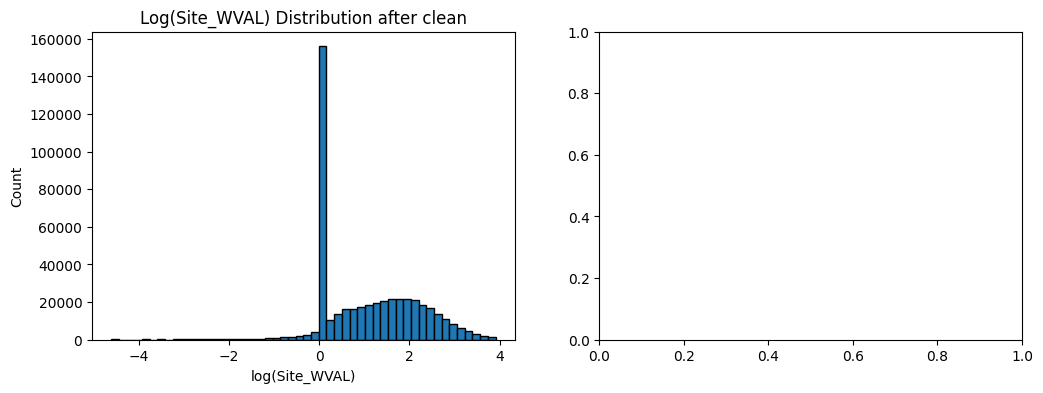

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log(df_clean[df_clean['Site_WVAL'] > 0]['Site_WVAL']), bins=50, edgecolor='black')
axes[0].set_title('Log(Site_WVAL) Distribution after clean')
axes[0].set_xlabel('log(Site_WVAL)')
axes[0].set_ylabel('Count')

In [12]:
df = df_clean

In [13]:
records_per_week = df['Week_End'].value_counts().rename('Total_Tests')
population_per_week = df.groupby(['Week_End', 'Site'])['Population_Served'].first().reset_index()
population_summary = population_per_week.groupby('Week_End')['Population_Served'].sum().rename('Total_Served')
sites_per_week = df.groupby('Week_End')['Site'].nunique().rename('Unique_sites_per_week')
weekly_summaries = pd.concat([records_per_week, population_summary, sites_per_week], axis=1).sort_index()

weekly_summaries['Total_Served'] = weekly_summaries['Total_Served'].astype(str).str.replace(',', '').astype(int)
weekly_summaries['Total_Served'] = weekly_summaries['Total_Served'].map('{:,}'.format)

total_pop = df.groupby(['State/Territory', 'Site'])['Population_Served'].first().sum().astype
data = { 
    'States': df['State/Territory'].value_counts(),
    'Sources': df['Source'].value_counts(),
    'Pathogen Targets': df['Pathogen_Target'].value_counts(),
    'Population': df['Population_Served'].describe(),
    'Sites/State': df.groupby('State/Territory')['Site'].nunique().sort_values(),
    'Total Population across Sites': pd.DataFrame([df.groupby(['State/Territory', 'Site'])['Population_Served'].first().sum()], columns=['Sum']),
    'Weekly Summary': weekly_summaries
}

/var/folders/mm/by8w7mxx5tg2g8gh4k18xr000000gn/T/ipykernel_51597/3775476800.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  weekly_summaries = pd.concat([records_per_week, population_summary, sites_per_week], axis=1).sort_index()


In [14]:
for i, d in data.items():
    print(f'{i}\n')
    display(pd.DataFrame(d.head(5)))
    

States



,count
State/Territory,
California,42512
Illinois,40123
New York,27979
Ohio,27579
Texas,23273


Sources



,count
Source,
State_Territory,332423
WastewaterSCAN,62229
CDC_Verily,38590
CDC_Biobot,16633
"State_Territory, WastewaterSCAN",13429


Pathogen Targets



...

,Site
State/Territory,
District of Columbia,1
North Dakota,2
Mississippi,4
South Dakota,4
Alaska,5


Total Population across Sites



,Sum
0,175930773


Weekly Summary



,Total_Tests,Total_Served,Unique_sites_per_week
Week_End,,,
2022-01-01,399,"54,395,783",363
2022-01-08,434,"55,737,869",406
2022-01-15,446,"57,084,915",413
2022-01-22,443,"58,706,044",416
2022-01-29,490,"61,859,718",457


In [15]:
weekly_summaries.describe()

,Total_Tests,Unique_sites_per_week
count,224.000000,224.000000
mean,2131.544643,1111.133929
std,732.028570,197.602082
min,399.000000,363.000000
25%,1676.500000,1098.000000
50%,2365.500000,1149.500000
75%,2775.250000,1237.000000
max,3001.000000,1334.000000


In [16]:



site_counts = df_clean.groupby('Site')['Site_WVAL'].count()
print("Distribution of observations per site:")
print(site_counts.describe())
site_counts.describe()
site_counts.value_counts().sort_index().head(20)




Distribution of observations per site:
count    1742.000000
mean      274.090700
std       169.712582
min         1.000000
25%       125.500000
50%       249.500000
75%       417.000000
max       654.000000
Name: Site_WVAL, dtype: float64


Site_WVAL
1      4
2      1
3      1
4      1
5      1
6      1
9      1
10     6
11    11
12     5
13     2
14     4
15     3
16     3
17     3
18     2
19     2
20     1
21     3
22     2
Name: count, dtype: int64

In [17]:
valid_sites = site_counts[site_counts >= 10].index


In [18]:
valid_sites

Index(['ID:10', 'ID:100', 'ID:1000', 'ID:1002', 'ID:1003', 'ID:1004',
       'ID:1005', 'ID:1006', 'ID:1007', 'ID:1008',
       ...
       'ID:99', 'ID:990', 'ID:991', 'ID:992', 'ID:993', 'ID:994', 'ID:995',
       'ID:996', 'ID:997', 'ID:998'],
      dtype='str', name='Site', length=1732)

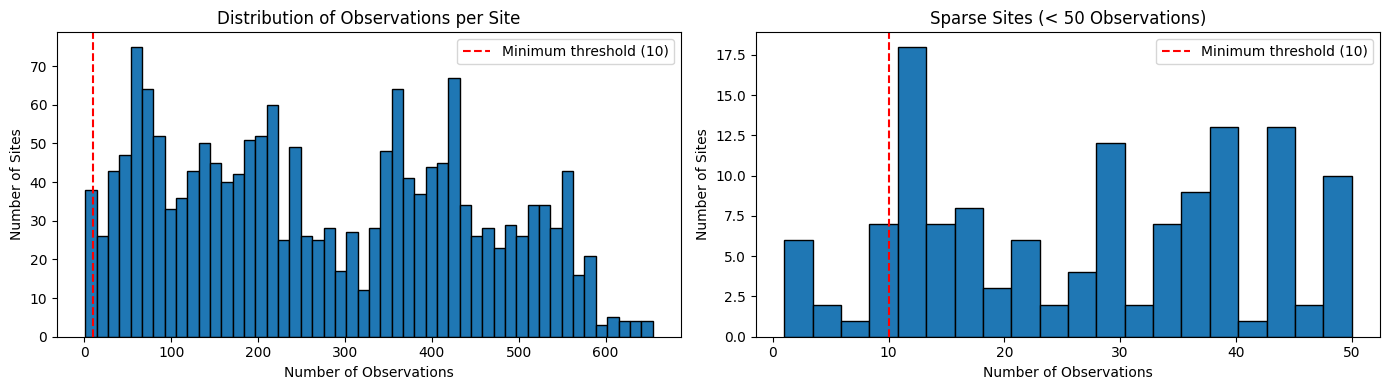

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(site_counts, bins=50, edgecolor='black')
axes[0].axvline(10, color='red', linestyle='--', label='Minimum threshold (10)')
axes[0].set_title('Distribution of Observations per Site')
axes[0].set_xlabel('Number of Observations')
axes[0].set_ylabel('Number of Sites')
axes[0].legend()

axes[1].hist(site_counts[site_counts <= 50], bins=20, edgecolor='black')
axes[1].axvline(10, color='red', linestyle='--', label='Minimum threshold (10)')
axes[1].set_title('Sparse Sites (< 50 Observations)')
axes[1].set_xlabel('Number of Observations')
axes[1].set_ylabel('Number of Sites')
axes[1].legend()

plt.tight_layout()
plt.savefig('site_obs_distribution.png', dpi=150)
plt.show()

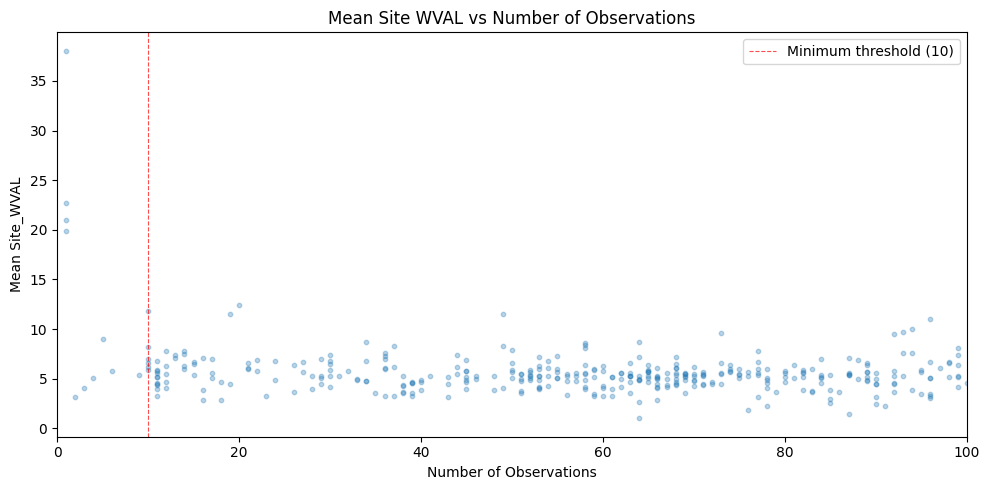

In [20]:
site_stats = pd.DataFrame({
    'count': site_counts,
    'mean_wval': df_clean.groupby('Site')['Site_WVAL'].mean()
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(site_stats['count'], site_stats['mean_wval'], alpha=0.3, s=10)
ax.axvline(10, color='red', linestyle='--', label='Minimum threshold (10)', linewidth=0.8, alpha=0.7)
ax.set_title('Mean Site WVAL vs Number of Observations')
ax.set_xlabel('Number of Observations')
ax.set_ylabel('Mean Site_WVAL')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('wval_vs_obs_count.png', dpi=150)
plt.show()

In [21]:
le_site = LabelEncoder()
le_site.fit(valid_sites)

le_state = LabelEncoder()
states = df_clean[df_clean['Site'].isin(valid_sites)]['State/Territory'].unique()
state_idx = le_state.fit_transform(states)

site_to_state_str = dict(zip(df_clean['Site'], df_clean['State/Territory']))

population_by_site = (df_clean[df_clean['Site'].isin(valid_sites)][['Site', 'Population_Served']]
                      .drop_duplicates(subset='Site'))

In [22]:
population_by_site

,Site,Population_Served
0,ID:4,30000
3,ID:5,77000
6,ID:6,225000
9,ID:7,200000
12,ID:8,95000
...,...,...
315635,ID:791,32000
337499,ID:1880,22275
352923,ID:354,3100
367509,ID:947,10681


In [23]:
site_to_state_idx = le_state.transform(
    [site_to_state_str[site] for site in le_site.classes_]
)

In [24]:
site_to_state_idx

array([ 0,  4, 24, ..., 24, 24, 24], shape=(1732,))

In [25]:
population_per_site = (population_by_site
    .assign(state=population_by_site['Site'].map(site_to_state_str))
    .groupby('Site')['Population_Served']
    .sum()
)

In [26]:
population_per_site

Site
ID:10        9000
ID:100      15372
ID:1000     23378
ID:1002     18544
ID:1003     16000
            ...  
ID:994      10787
ID:995      49117
ID:996     185832
ID:997     255624
ID:998      22154
Name: Population_Served, Length: 1732, dtype: int64

In [27]:
population_per_site = population_per_site.to_numpy()

In [28]:
log_pop = np.log(population_per_site)
pop_std = (log_pop - log_pop.mean()) / log_pop.std()

In [29]:
pop_std

array([-0.86061278, -0.48822002, -0.19657405, ...,  1.24552314,
        1.46733845, -0.23398378], shape=(1732,))

In [30]:
wvals = df[df['Site'].isin(valid_sites)][['Site_WVAL', 'Site']].groupby('Site').mean()


In [31]:
wvals.describe()

,Site_WVAL
count,1732.000000
mean,5.306400
std,1.366338
min,1.000000
25%,4.466975
50%,5.137018
75%,5.883732
max,16.552797


In [32]:
wvals_per_site_means = wvals['Site_WVAL'].to_numpy()

In [33]:
wvals_per_site_means.shape


(1732,)

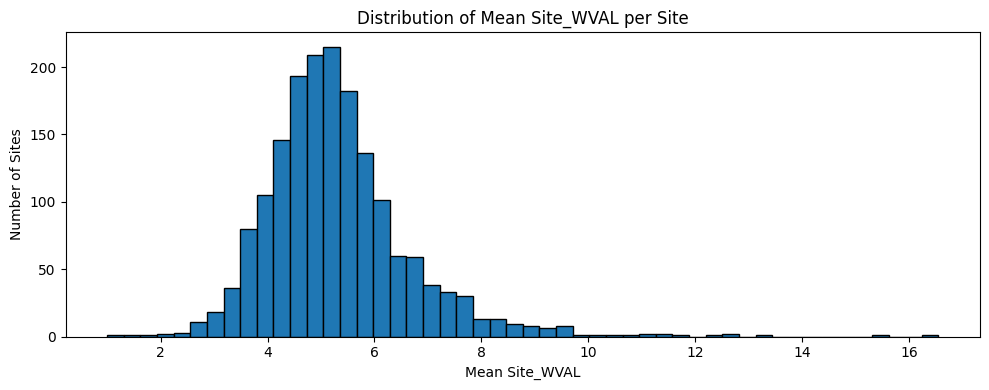

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(wvals['Site_WVAL'], bins=50, edgecolor='black')
ax.set_title('Distribution of Mean Site_WVAL per Site')
ax.set_xlabel('Mean Site_WVAL')
ax.set_ylabel('Number of Sites')
plt.tight_layout()
plt.savefig('mean_wval_per_site.png', dpi=150)
plt.show()

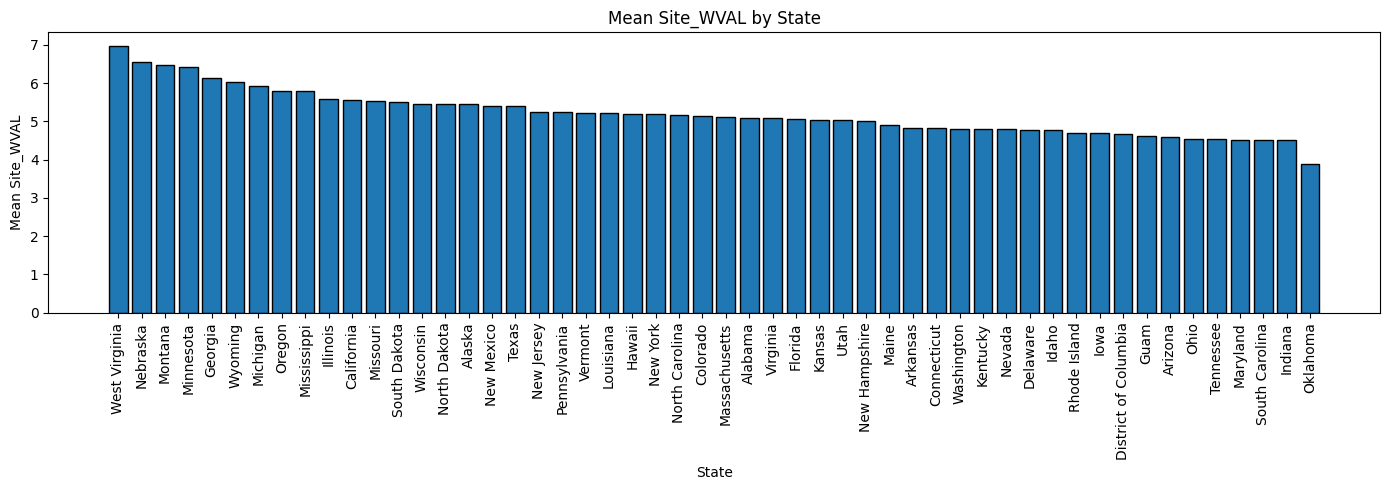

In [35]:
state_wvals = (df_clean[df_clean['Site'].isin(valid_sites)]
               .groupby('State/Territory')['Site_WVAL']
               .mean()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(state_wvals.index, state_wvals.values, edgecolor='black')
ax.set_title('Mean Site_WVAL by State')
ax.set_xlabel('State')
ax.set_ylabel('Mean Site_WVAL')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('mean_wval_by_state.png', dpi=150)
plt.show()

In [36]:
pop_std.shape

(1732,)

In [37]:
x = pop_std

x_std = (x-x.mean(axis=0))/ x.std(axis=0)

y = wvals_per_site_means

In [38]:
print(valid_sites.shape)
print(states.shape)

(1732,)
(52,)


In [39]:
print(y.shape)

(1732,)


In [40]:
with pm.Model() as model:
    mu_global = pm.Normal("mu_global", mu=5, sigma=1)
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=0.5)
    sigma_state = pm.HalfNormal("sigma_state", sigma=1)

    state_offset_raw = pm.Normal("state_offset_raw", mu=0, sigma=1, shape=states.shape)
    state_offset = pm.Deterministic("state_offset", state_offset_raw * sigma_state)



    sigma_site = pm.HalfNormal("sigma_site", sigma=0.5)
    site_offset_raw = pm.Normal("site_offset_raw", mu=0, sigma=1, shape=valid_sites.shape) 
    site_offset = pm.Deterministic("site_offset", site_offset_raw * sigma_site)


    mu = mu_global + beta_pop * x_std + state_offset[site_to_state_idx] + site_offset
        
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma_site, observed=y)



    trace_1 = pm.sample(
            3000, 
            tune=2000, 
            target_accept=0.98,
            chains=4,
            init="auto"
        )
    

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, beta_pop, sigma_state, state_offset_raw, sigma_site, site_offset_raw]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 28 seconds.


In [41]:
summary = az.summary(trace_1, var_names=["mu_global", "beta_pop", "sigma_state", "sigma_site"])

In [42]:
with model:
    for name, var in model.named_vars.items():
        try:
            print(name, pm.str_for_dist(var, formatting='latex'))
        except:
            pass

mu_global $\text{mu\_global} \sim \operatorname{Normal}(5,~1)$
beta_pop $\text{beta\_pop} \sim \operatorname{Normal}(0,~0.5)$
sigma_state $\text{sigma\_state} \sim \operatorname{HalfNormal}(0,~1)$
state_offset_raw $\text{state\_offset\_raw} \sim \operatorname{Normal}(0,~1)$
state_offset $\text{state\_offset} \sim Unknown(f(\text{state_offset_raw},~\text{sigma_state}))$
sigma_site $\text{sigma\_site} \sim \operatorname{HalfNormal}(0,~0.5)$
site_offset_raw $\text{site\_offset\_raw} \sim \operatorname{Normal}(0,~1)$
site_offset $\text{site\_offset} \sim Unknown(f(\text{site_offset_raw},~\text{sigma_site}))$
likelihood $\text{likelihood} \sim \operatorname{Normal}(f(\text{site_offset_raw},~\text{mu_global},~\text{sigma_site},~\text{state_offset_raw},~\text{beta_pop},~\text{sigma_state}),~\text{sigma_site})$


In [43]:
prior_samples = pm.sample_prior_predictive(model=model, samples=1000)


Sampling: [beta_pop, likelihood, mu_global, sigma_site, sigma_state, site_offset_raw, state_offset_raw]


In [44]:
prior_summary = az.summary(prior_samples, kind="stats", hdi_prob=0.95)


In [45]:
prior_summary

,mean,sd,hdi_2.5%,hdi_97.5%
sigma_site,0.397,0.294,0.004,0.950
sigma_state,0.808,0.608,0.000,1.992
site_offset[0],0.008,0.515,-1.050,1.110
site_offset[1],-0.003,0.494,-1.058,1.069
site_offset[2],-0.001,0.511,-0.901,1.238
...,...,...,...,...
site_offset_raw[1727],-0.017,0.961,-1.899,1.822
site_offset_raw[1728],-0.004,0.977,-1.864,1.927
site_offset_raw[1729],0.061,1.073,-1.916,2.277
site_offset_raw[1730],-0.017,0.985,-1.827,2.081


In [46]:
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,5.229,0.085,5.066,5.388,0.001,0.001,5242.0,7568.0,1.0
beta_pop,0.089,0.033,0.028,0.153,0.000,0.000,13862.0,10562.0,1.0
sigma_state,0.531,0.070,0.405,0.665,0.001,0.001,5419.0,8583.0,1.0
sigma_site,0.910,0.016,0.880,0.939,0.000,0.000,16807.0,10508.0,1.0


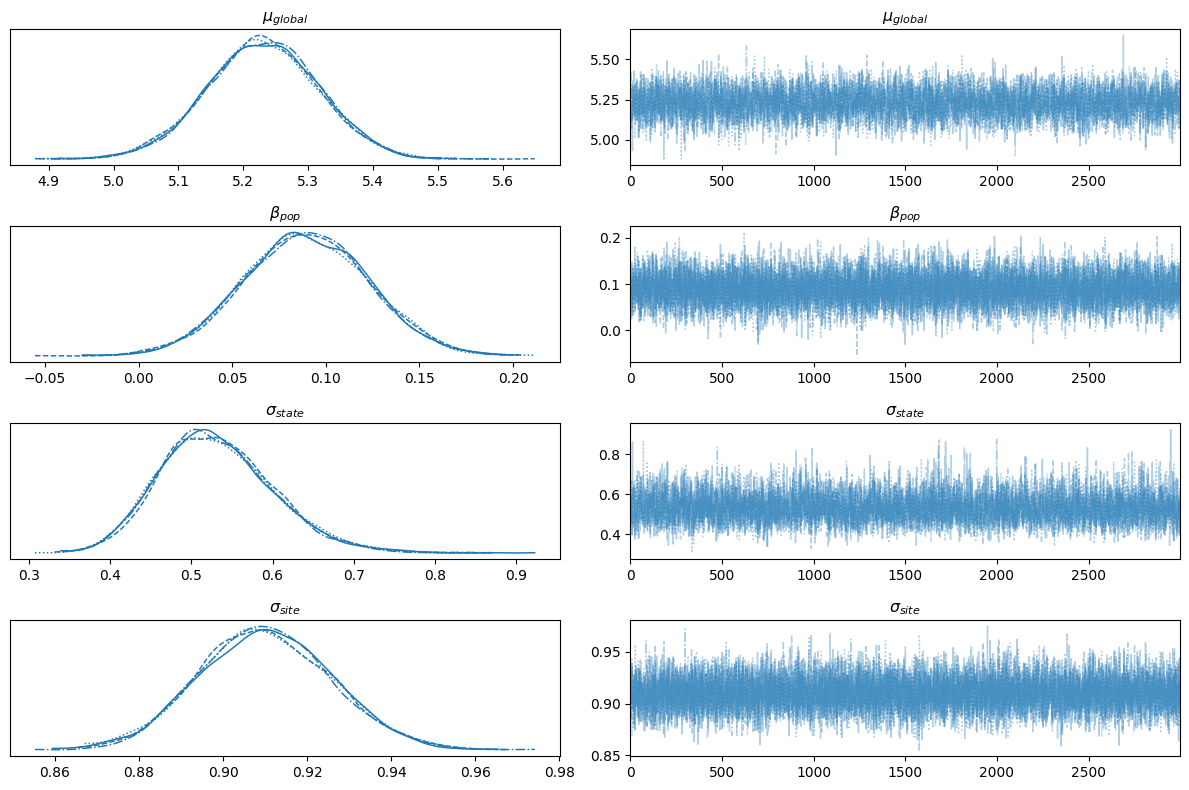

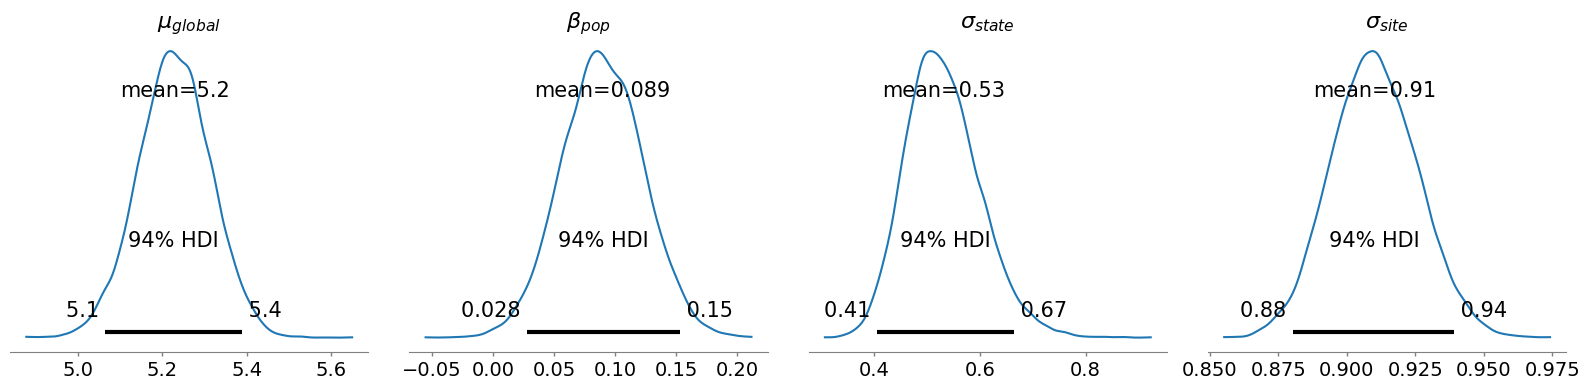

In [79]:
labels_1 = MapLabeller(var_name_map={                                                                                                          
    "mu_global":   r"$\mu_{global}$",                                                                                                          
    "beta_pop":    r"$\beta_{pop}$",                                                                                                           
    "sigma_state": r"$\sigma_{state}$",                                                                                                        
    "sigma_site":  r"$\sigma_{site}$",                                                                                                         
})

az.plot_trace(trace_1, var_names=["mu_global", "beta_pop", "sigma_state", "sigma_site"],labeller=labels_1) 
plt.tight_layout()
plt.savefig('model1_trace.png', dpi=150)
plt.tight_layout()
plt.show()

az.plot_posterior(trace_1, var_names=["mu_global", "beta_pop", "sigma_state", "sigma_site"],labeller=labels_1,figsize=(16, 4))
plt.tight_layout()
plt.savefig('model1_posterior.png', dpi=150)
plt.tight_layout()
plt.show()

In [49]:
wvals = (df_clean[df_clean['Site'].isin(valid_sites)]
         .groupby(['Site', 'Pathogen_Target'])['Site_WVAL']
         .mean())

In [50]:
pathogen_counts = (df_clean[df_clean['Site'].isin(valid_sites)]
                   .groupby(['Site', 'Pathogen_Target'])
                   .size()
                   .unstack(fill_value=0))

In [51]:
pathogen_counts

Pathogen_Target,Influenza A virus,RSV,SARS-CoV-2
Site,,,
ID:10,0,0,37
ID:100,129,129,129
ID:1000,0,0,197
ID:1002,38,39,209
ID:1003,152,153,152
...,...,...,...
ID:994,0,0,139
ID:995,0,0,118
ID:996,37,0,199


Sites reporting each pathogen:
Pathogen_Target
Influenza A virus    1180
RSV                  1067
SARS-CoV-2           1722
Name: Site, dtype: int64

Unique weeks per pathogen:
Pathogen_Target
Influenza A virus    224
RSV                  215
SARS-CoV-2           224
Name: Week_End, dtype: int64

Sites reporting all 3 pathogens: 1044
Sites reporting 1-2 pathogens: 688


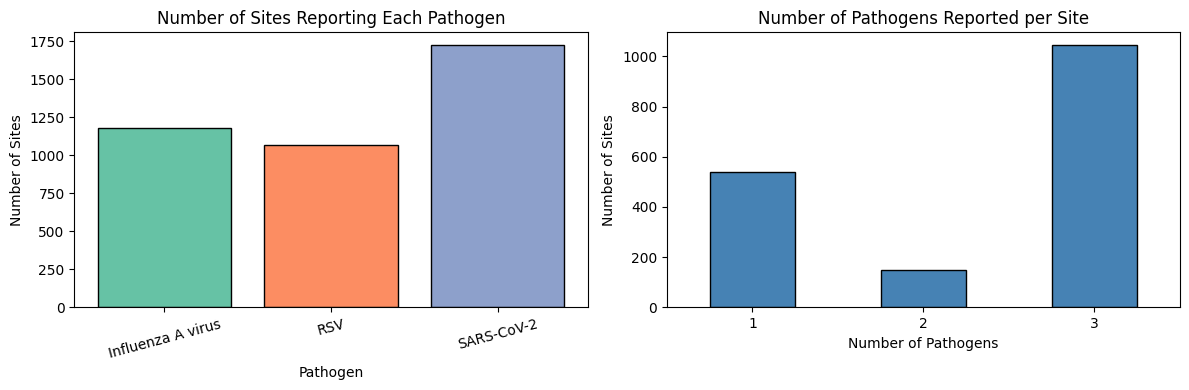

In [52]:
pathogen_site_counts = df_clean[df_clean['Site'].isin(valid_sites)].groupby('Pathogen_Target')['Site'].nunique()
pathogen_week_counts = df_clean[df_clean['Site'].isin(valid_sites)].groupby('Pathogen_Target')['Week_End'].nunique()
sites_per_pathogen = df_clean[df_clean['Site'].isin(valid_sites)].groupby('Site')['Pathogen_Target'].nunique()

print("Sites reporting each pathogen:")
print(pathogen_site_counts)
print("\nUnique weeks per pathogen:")
print(pathogen_week_counts)
print(f"\nSites reporting all 3 pathogens: {(sites_per_pathogen == 3).sum()}")
print(f"Sites reporting 1-2 pathogens: {(sites_per_pathogen < 3).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(pathogen_site_counts.index, pathogen_site_counts.values, edgecolor='black', color=['#66c2a5','#fc8d62','#8da0cb'])
axes[0].set_title('Number of Sites Reporting Each Pathogen')
axes[0].set_xlabel('Pathogen')
axes[0].set_ylabel('Number of Sites')
axes[0].tick_params(axis='x', rotation=15)

sites_per_pathogen.value_counts().sort_index().plot(kind='bar', ax=axes[1], edgecolor='black', color='steelblue')
axes[1].set_title('Number of Pathogens Reported per Site')
axes[1].set_xlabel('Number of Pathogens')
axes[1].set_ylabel('Number of Sites')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('pathogen_coverage.png', dpi=150)
plt.show()

In [53]:
all_three = pathogen_counts[(pathogen_counts > 0).all(axis=1)]
print(f"Sites retained (all 3 pathogens): {len(all_three)}")
print(f"Sites excluded (missing pathogen): {len(pathogen_counts) - len(all_three)}")

Sites retained (all 3 pathogens): 1044
Sites excluded (missing pathogen): 688


In [54]:
all_three = pathogen_counts[(pathogen_counts > 0).all(axis=1)]
all_three

Pathogen_Target,Influenza A virus,RSV,SARS-CoV-2
Site,,,
ID:100,129,129,129
ID:1002,38,39,209
ID:1003,152,153,152
ID:1004,39,40,201
ID:101,108,108,171
...,...,...,...
ID:98,133,134,190
ID:99,192,191,192
ID:990,43,61,114


In [55]:
pathogen_props = all_three.div(all_three.sum(axis=1), axis=0)
pathogen_props.sum(axis=1).describe()

count    1.044000e+03
mean     1.000000e+00
std      1.684123e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

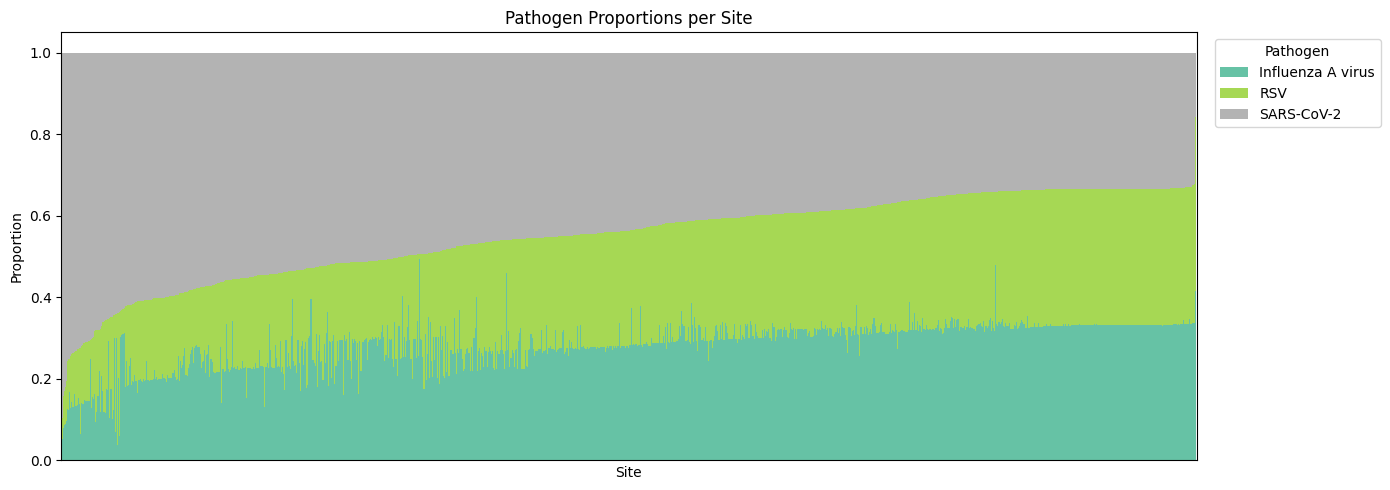

In [56]:
pathogen_props_sorted = pathogen_props.sort_values('SARS-CoV-2', ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
pathogen_props_sorted.plot(kind='bar', stacked=True, ax=ax, 
                           colormap='Set2', edgecolor='none', width=1.0)
ax.set_title('Pathogen Proportions per Site')
ax.set_xlabel('Site')
ax.set_ylabel('Proportion')
ax.set_xticks([])
ax.legend(title='Pathogen', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pathogen_proportions.png', dpi=150)
plt.show()

In [57]:
site_state = (df_clean[df_clean['Site'].isin(all_three.index)]
              [['Site', 'State/Territory']]
              .drop_duplicates(subset='Site'))

In [58]:
site_state

,Site,State/Territory
0,ID:4,Alabama
3,ID:5,Alabama
6,ID:6,Alabama
9,ID:7,Alabama
12,ID:8,Alabama
...,...,...
200988,ID:2522,Oregon
204080,ID:1715,Oregon
263504,ID:724,Maine
267563,ID:2280,Texas


In [59]:
le_state = LabelEncoder()
states = site_state['State/Territory']
state_idx = le_state.fit_transform(states)

le_site = LabelEncoder()
le_site.fit(all_three.index)

site_to_state_str = dict(zip(df_clean['Site'], df_clean['State/Territory']))

population_by_site = (df_clean[df_clean['Site'].isin(all_three.index)][['Site', 'Population_Served']]
                      .drop_duplicates(subset='Site'))

In [60]:
state_idx.shape

(1044,)

In [61]:
site_to_state_idx = le_state.transform(
    [site_to_state_str[site] for site in le_site.classes_]
)

In [62]:
site_to_state_idx

array([ 4, 24, 24, ..., 23, 24, 24], shape=(1044,))

In [63]:
population_per_site = (population_by_site
    .assign(state=population_by_site['Site'].map(site_to_state_str))
    .groupby('Site')['Population_Served']
    .sum()
)

In [64]:
log_pop = np.log(population_per_site)
pop_std = (log_pop - log_pop.mean()) / log_pop.std()

In [65]:
print(pathogen_props.shape) 
print(site_to_state_idx.shape) 
print(pop_std.shape) 

(1044, 3)
(1044,)
(1044,)


In [66]:
log_pop = np.log(population_by_site.set_index('Site').loc[le_site.classes_, 'Population_Served'])
x = (log_pop - log_pop.mean()) / log_pop.std()
x = x.to_numpy()

In [67]:
with pm.Model() as model_2:

    
    mu_global = pm.Normal("mu_global", mu=0, sigma=1, shape=pathogen_props.shape[1])
    beta_pop = pm.Normal("beta_pop", mu=0, sigma=0.5, shape=pathogen_props.shape[1])
    concentration = pm.math.exp(mu_global + beta_pop * x[:, None])

    pm.Dirichlet("y", a=concentration, observed=pathogen_props)


    trace_2 = pm.sample(
            3000, 
            tune=2000, 
            target_accept=0.98,
            chains=4,
            init="auto"
        )
    

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, beta_pop]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 30 seconds.


In [68]:
with model_2:
    for name, var in model_2.named_vars.items():
        try:
            print(pm.str_for_dist(var, formatting='latex'))
        except:
            pass

$\text{mu\_global} \sim \operatorname{Normal}(0,~1)$
$\text{beta\_pop} \sim \operatorname{Normal}(0,~0.5)$
$\text{y} \sim \operatorname{Dirichlet}(f(\text{mu_global},~\text{beta_pop}))$


In [74]:
pathogen_names = list(pathogen_props.columns) 
trace_2.posterior = trace_2.posterior.assign_coords(                                                                                           
    mu_global_dim_0=pathogen_names,                                                                                                            
    beta_pop_dim_0=pathogen_names,                                                                                                             
)      

prior_samples = pm.sample_prior_predictive(model=model_2, samples=1000)
summary = az.summary(trace_2)
prior_summary = az.summary(prior_samples, kind="stats", hdi_prob=0.95)

for i, name in enumerate(pathogen_counts.columns):
    summary.index = summary.index.str.replace(f'mu_global[{i}]', f'mu_global[{name}]', regex=False)
    summary.index = summary.index.str.replace(f'beta_pop[{i}]', f'beta_pop[{name}]', regex=False)
    prior_summary.index = summary.index.str.replace(f'mu_global[{i}]', f'mu_global[{name}]', regex=False)
    prior_summary.index = summary.index.str.replace(f'beta_pop[{i}]', f'beta_pop[{name}]', regex=False)

Sampling: [beta_pop, mu_global, y]


In [75]:
prior_summary

,mean,sd,hdi_2.5%,hdi_97.5%
mu_global[Influenza A virus],-0.023,0.964,-1.850,1.866
mu_global[RSV],-0.035,1.009,-2.108,1.873
mu_global[SARS-CoV-2],-0.002,0.981,-1.988,1.726
beta_pop[Influenza A virus],-0.014,0.491,-1.017,0.856
beta_pop[RSV],0.005,0.519,-1.027,0.954
beta_pop[SARS-CoV-2],-0.003,0.526,-0.946,1.053


In [76]:
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global[Influenza A virus],2.311,0.031,2.252,2.370,0.000,0.0,3926.0,5159.0,1.0
mu_global[RSV],2.234,0.031,2.176,2.293,0.001,0.0,3831.0,4892.0,1.0
mu_global[SARS-CoV-2],2.755,0.031,2.697,2.814,0.001,0.0,3795.0,4545.0,1.0
beta_pop[Influenza A virus],0.148,0.030,0.091,0.203,0.001,0.0,3400.0,4165.0,1.0
beta_pop[RSV],0.128,0.030,0.072,0.183,0.001,0.0,3445.0,4114.0,1.0
beta_pop[SARS-CoV-2],0.092,0.031,0.032,0.148,0.001,0.0,3405.0,4315.0,1.0


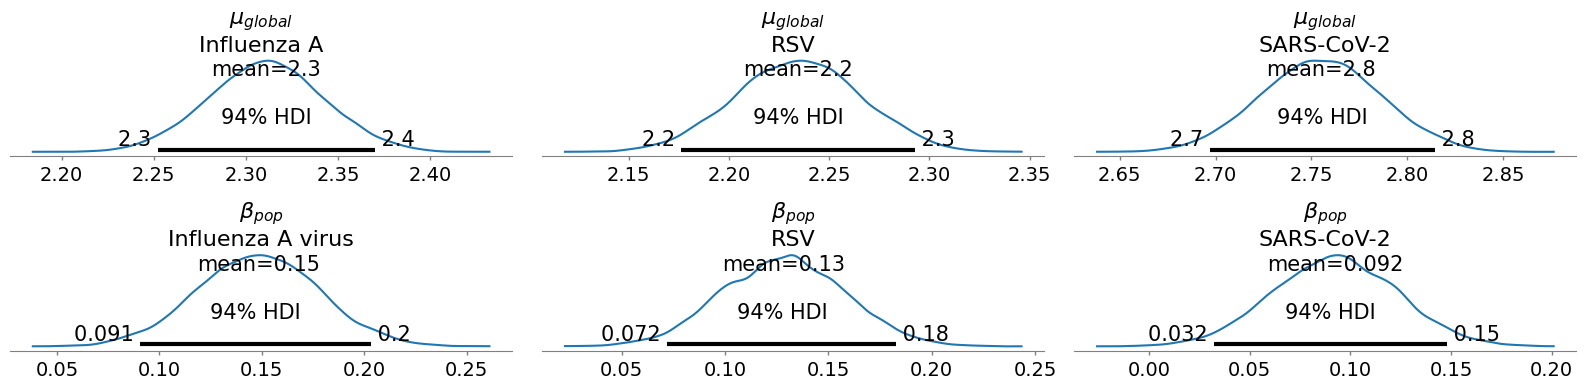

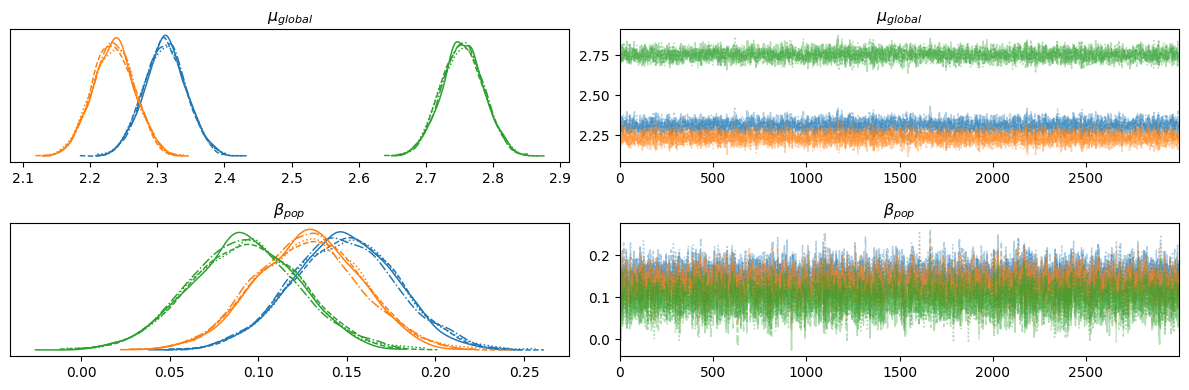

In [ ]:
labels_2 = MapLabeller(                                                                                                                        
    var_name_map={
        "mu_global": r"$\mu_{global}$",                                                                                                        
        "beta_pop":  r"$\beta_{pop}$",                                                                                                         
    },
    coord_map={                                                                                                                                
        "mu_global_dim_0": {
            "Influenza A virus": "Influenza A",
            "RSV": "RSV",                                                                                                                      
            "SARS-CoV-2": "SARS-CoV-2",
        }                                                                                                                                      
    }           
)


az.plot_posterior(trace_2, var_names=["mu_global", "beta_pop"],labeller=labels_2,figsize=(16, 4))
plt.tight_layout()
plt.savefig('model2_posterior.png', dpi=150)
plt.show()

az.plot_trace(trace_2, var_names=["mu_global", "beta_pop"],labeller=labels_2)
plt.tight_layout()
plt.savefig('model2_trace.png', dpi=150)
plt.show()